# High-Frequency Market Data: Could You Guess the Stock?
## Data Challenge CFM - ENS 2024 

**Étudiants :** Yassine Mannai & Hugo Rocha Mondragon  
**Enseignant :** Arthur Thomas (Groupe 2)  
**Date limite :** 17 avril 2026

---

**Problématique :** Identifier à quel titre financier (parmi 24 stocks) appartient une séquence de 100 événements tick-by-tick extraits du carnet d'ordres agrégé.  
Il s'agit d'un problème de **classification multi-classes** (24 classes) évalué à l'**accuracy**.

**Plan du notebook :**
1. Présentation de la problématique
2. Chargement et décomposition des données
3. Feature engineering & statistiques descriptives
4. Modèle de référence (Decision Tree)
5. Modèle non supervisé (Clustering — KMeans)
6. Modèle supervisé (Random Forest + SVM)
7. Interprétation (Feature Importance + SHAP)
8. Méthode ensembliste supplémentaire (Gradient Boosting)
9. Comparaison des modèles & Conclusion

In [34]:
# ── Imports ─────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
    )
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("tab10")
print("Imports OK — Python", __import__("sys").version.split()[0])

Imports OK — Python 3.13.12


---
## 1. Présentation de la problématique

Le challenge CFM / ENS 2024 porte sur la **microstructure des marchés financiers**.  
Chaque observation est une séquence de **100 événements consécutifs** du carnet d'ordres agrégé (plusieurs places de marché : NASDAQ, BATY, …).  

L'objectif est d'**identifier le titre financier** (parmi 24 stocks anonymisés) à partir de cette séquence tick-by-tick.

**Intuition :** chaque action a une "empreinte" microstructurelle caractéristique :
- Niveau de liquidité (spread, taille des ordres)
- Fréquence des trades vs. annulations
- Distribution des prix relatifs
- Comportement des market makers par venue

La métrique d'évaluation est l'**accuracy** :
$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

---
## 2. Chargement et décomposition des données

Les données brutes contiennent ~24,2 millions de lignes (100 événements × 242 400 séquences).  
Pour les calculs sur machine locale, on peut réduire l'échantillon en **conservant la même distribution des classes**.

In [14]:
DATA_DIR = "../data"

# ── Chargement ────────────────────────────────────────────────────────────────
print("Chargement des données…")
X_raw   = pd.read_csv(f"{DATA_DIR}/X_train_N1UvY30.csv")
y_raw   = pd.read_csv(f"{DATA_DIR}/y_train_or6m3Ta.csv")
X_test_raw = pd.read_csv(f"{DATA_DIR}/X_test_m4HAPAP.csv")

print(f"X_train : {X_raw.shape}  |  y_train : {y_raw.shape}  |  X_test : {X_test_raw.shape}")
print(f"\nColonnes X : {X_raw.columns.tolist()}")
X_raw.head(3)

Chargement des données…
X_train : (16080000, 12)  |  y_train : (160800, 2)  |  X_test : (8160000, 12)

Colonnes X : ['obs_id', 'venue', 'order_id', 'action', 'side', 'price', 'bid', 'ask', 'bid_size', 'ask_size', 'trade', 'flux']


,obs_id,venue,order_id,action,side,price,bid,ask,bid_size,ask_size,trade,flux
0,0,4,0,A,A,0.30,0.0,0.01,100,1,False,100
1,0,4,1,A,B,-0.17,0.0,0.01,100,1,False,100
2,0,4,2,D,A,0.28,0.0,0.01,100,1,False,-100


Colonne cible : 'eqt_code_cat'  |  24 classes
eqt_code_cat
0     6700
1     6700
2     6700
3     6700
4     6700
5     6700
6     6700
7     6700
8     6700
9     6700
10    6700
11    6700
12    6700
13    6700
14    6700
15    6700
16    6700
17    6700
18    6700
19    6700
20    6700
21    6700
22    6700
23    6700
Name: count, dtype: int64


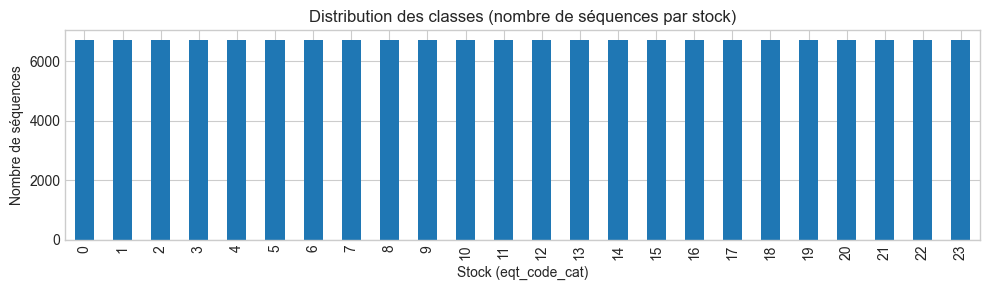

In [15]:
# ── Distribution des classes ──────────────────────────────────────────────────
label_col = y_raw.columns[-1]   # "eqt_code_cat"
print(f"Colonne cible : '{label_col}'  |  {y_raw[label_col].nunique()} classes")
print(y_raw[label_col].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 3))
y_raw[label_col].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribution des classes (nombre de séquences par stock)")
ax.set_xlabel("Stock (eqt_code_cat)")
ax.set_ylabel("Nombre de séquences")
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Statistiques Descriptives

Les données brutes ont **100 lignes par séquence** (`obs_id`).  
Pour les modèles classiques (non-séquentiels), on **agrège** ces 100 événements en un vecteur de features par séquence.

**Features construites :**
- Statistiques (mean, std, min, max) de : `price`, `bid`, `ask`, `bid_size`, `ask_size`, `flux`
- Spread moyen : `ask - bid`
- Taux de trades : proportion d'événements avec `trade = True`
- Distribution des actions : proportion de `A`, `D`, `U`
- Distribution des côtés : proportion `B`, `A`
- Nombre de venues distinctes

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Agrège les 100 événements par obs_id en un vecteur de features."""
    grp = df.groupby("obs_id")

    with tqdm(total=6, desc="Features par obs_id", leave=False) as pbar:
        # Statistiques numériques
        num_cols = ["price", "bid", "ask", "bid_size", "ask_size", "flux"]
        agg = grp[num_cols].agg(["mean", "std", "min", "max"])
        agg.columns = ["_".join(c) for c in agg.columns]
        pbar.update(1)

        # Spread (ask - bid) stats
        df_tmp = df.copy()
        df_tmp["spread"] = df_tmp["ask"] - df_tmp["bid"]
        spread_agg = df_tmp.groupby("obs_id")["spread"].agg(["mean", "std", "min", "max"])
        spread_agg.columns = ["spread_mean", "spread_std", "spread_min", "spread_max"]
        pbar.update(1)

        # Taux de trades
        trade_rate = grp["trade"].mean().rename("trade_rate")
        pbar.update(1)

        # Distribution des actions (A=add, D=delete, U=update)
        action_dummies = pd.get_dummies(df["action"], prefix="action")
        action_dummies["obs_id"] = df["obs_id"].values
        action_agg = action_dummies.groupby("obs_id").mean()
        pbar.update(1)

        # Distribution des côtés (B=bid, A=ask)
        side_dummies = pd.get_dummies(df["side"], prefix="side")
        side_dummies["obs_id"] = df["obs_id"].values
        side_agg = side_dummies.groupby("obs_id").mean()
        pbar.update(1)

        # Nombre de venues distinctes
        n_venues = grp["venue"].nunique().rename("n_venues")
        pbar.update(1)

    feats = pd.concat([agg, spread_agg, trade_rate, action_agg, side_agg, n_venues], axis=1)
    return feats.reset_index()

print("Construction des features en cours…")
feature_sets = {}
for split_name, split_df in tqdm([("train", X_raw), ("test", X_test_raw)], desc="Agrégation des datasets"):
    feature_sets[split_name] = build_features(split_df)

X_feats_train = feature_sets["train"]
X_feats_test  = feature_sets["test"]
print(f"Features train : {X_feats_train.shape}  |  Features test : {X_feats_test.shape}")
X_feats_train.head(3)

Construction des features en cours…
Features train : (160800, 36)  |  Features test : (81600, 36)


,obs_id,price_mean,price_std,price_min,price_max,bid_mean,bid_std,bid_min,bid_max,ask_mean,...,spread_std,spread_min,spread_max,trade_rate,action_A,action_D,action_U,side_A,side_B,n_venues
0,0,0.0535,0.172588,-0.29,0.44,0.0000,0.000000,0.0,0.00,0.0152,...,0.005021,0.01,0.02,0.00,0.51,0.49,0.00,0.48,0.52,6
1,1,-0.0257,0.182791,-0.79,0.25,0.0134,0.010466,0.0,0.04,0.0526,...,0.006917,0.02,0.06,0.03,0.49,0.43,0.08,0.32,0.68,6
2,2,0.0120,0.054198,-0.16,0.14,0.0000,0.000000,0.0,0.00,0.0107,...,0.002564,0.01,0.02,0.01,0.54,0.46,0.00,0.56,0.44,6


In [17]:
# ── Fusion avec les labels & préparation du jeu ML ───────────────────────────
y_indexed = y_raw.set_index(y_raw.columns[0])  # obs_id en index
X_ml = X_feats_train.set_index("obs_id")
y_ml = y_indexed.loc[X_ml.index, label_col].values

feature_names = X_ml.columns.tolist()
print(f"Jeu ML : {X_ml.shape[0]} séquences × {X_ml.shape[1]} features")
print(f"Features : {feature_names[:10]} …")

# ── Split train / validation ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)
print(f"\nTrain : {X_train.shape[0]}  |  Validation : {X_val.shape[0]}")

Jeu ML : 160800 séquences × 35 features
Features : ['price_mean', 'price_std', 'price_min', 'price_max', 'bid_mean', 'bid_std', 'bid_min', 'bid_max', 'ask_mean', 'ask_std'] …

Train : 128640  |  Validation : 32160


In [18]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
print("=== Statistiques des features (train) ===")
X_train.describe().round(3)

=== Statistiques des features (train) ===


,price_mean,price_std,price_min,price_max,bid_mean,bid_std,bid_min,bid_max,ask_mean,ask_std,...,spread_std,spread_min,spread_max,trade_rate,action_A,action_D,action_U,side_A,side_B,n_venues
count,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,...,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000
mean,0.923,3.208,-2.447,22.197,0.000,0.009,-0.012,0.014,0.602,0.009,...,0.011,0.582,0.617,0.005,0.496,0.495,0.009,0.498,0.502,5.697
std,34.955,235.294,15.705,1930.886,0.028,0.026,0.027,0.054,11.013,0.048,...,0.053,11.013,11.013,0.011,0.040,0.040,0.016,0.163,0.163,0.574
min,-170.476,0.000,-569.770,-169.840,-0.507,0.000,-0.760,0.000,-380.590,0.000,...,0.000,-380.600,-380.580,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,-0.016,0.125,-2.340,0.320,-0.004,0.000,-0.010,0.000,0.016,0.000,...,0.003,0.010,0.020,0.000,0.470,0.470,0.000,0.380,0.390,5.000
50%,0.015,0.274,-0.610,0.700,0.000,0.005,0.000,0.000,0.038,0.005,...,0.006,0.020,0.050,0.000,0.500,0.500,0.000,0.500,0.500,6.000
75%,0.075,0.825,-0.270,2.490,0.005,0.011,0.000,0.010,0.080,0.011,...,0.013,0.050,0.100,0.000,0.520,0.520,0.010,0.610,0.620,6.000
max,7992.074,39367.781,266.410,199976.330,6.306,7.927,0.000,16.170,267.924,15.945,...,15.929,267.880,267.940,0.220,1.000,1.000,0.350,1.000,1.000,6.000


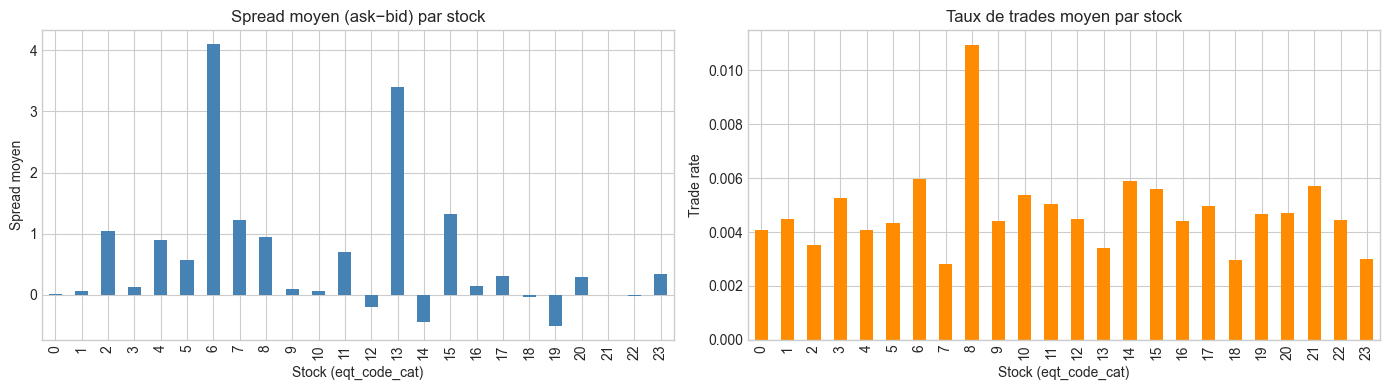

In [19]:
# ── Visualisation : spread moyen par classe ────────────────────────────────────
df_eda = X_train.copy()
df_eda["label"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spread moyen par stock
df_eda.groupby("label")["spread_mean"].mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Spread moyen (ask−bid) par stock")
axes[0].set_xlabel("Stock (eqt_code_cat)")
axes[0].set_ylabel("Spread moyen")

# Trade rate par stock
df_eda.groupby("label")["trade_rate"].mean().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Taux de trades moyen par stock")
axes[1].set_xlabel("Stock (eqt_code_cat)")
axes[1].set_ylabel("Trade rate")

plt.tight_layout()
plt.show()

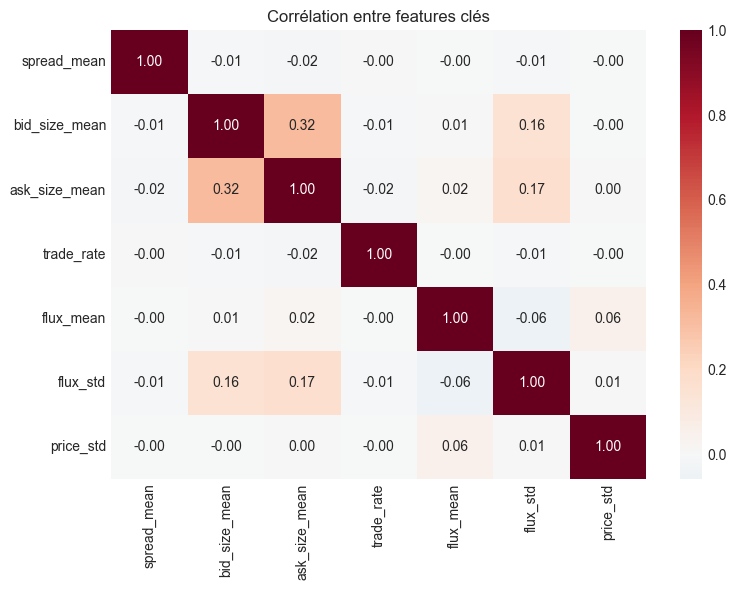

In [20]:
# ── Matrice de corrélation des features principales ───────────────────────────
key_feats = ["spread_mean", "bid_size_mean", "ask_size_mean", "trade_rate",
             "flux_mean", "flux_std", "price_std"]
corr = X_train[key_feats].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Corrélation entre features clés")
plt.tight_layout()
plt.show()

---
## 4. Modèle de Référence — Arbre de Décision

On entraîne un **arbre de décision** comme baseline simple.  
Ce modèle est facilement interprétable et servira de référence pour évaluer les modèles plus complexes.

**Métrique :** Accuracy sur la validation (20% du train).

Accuracy Decision Tree (val) : 0.3253  (32.53%)
Baseline naïf (random) : 0.0417  (4.17%)


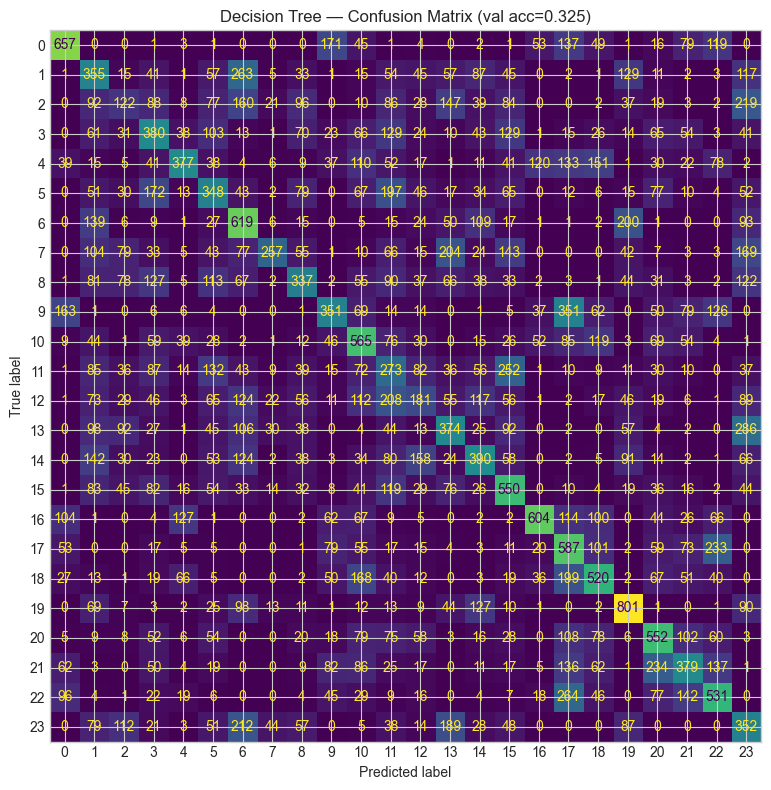

In [21]:
# ── Arbre de Décision (baseline) ──────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f"Accuracy Decision Tree (val) : {acc_dt:.4f}  ({acc_dt*100:.2f}%)")
print(f"Baseline naïf (random) : {1/24:.4f}  ({100/24:.2f}%)")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt, ax=ax, colorbar=False)
ax.set_title(f"Decision Tree — Confusion Matrix (val acc={acc_dt:.3f})")
plt.tight_layout()
plt.show()

---
## 5. Modèle Non Supervisé — Clustering (KMeans)

On applique un **KMeans** avec **k = 24** (le nombre de stocks connus) sur nos features.  
L'objectif est d'explorer si les séquences se regroupent naturellement par stock — ce qui validerait la pertinence des features construites.

**Évaluation :** On mesure l'accord entre les clusters et les vraies étiquettes via l'*accuracy après alignement optimal* (Hungarian algorithm / best permutation).

Inertie KMeans (train) : 1510118


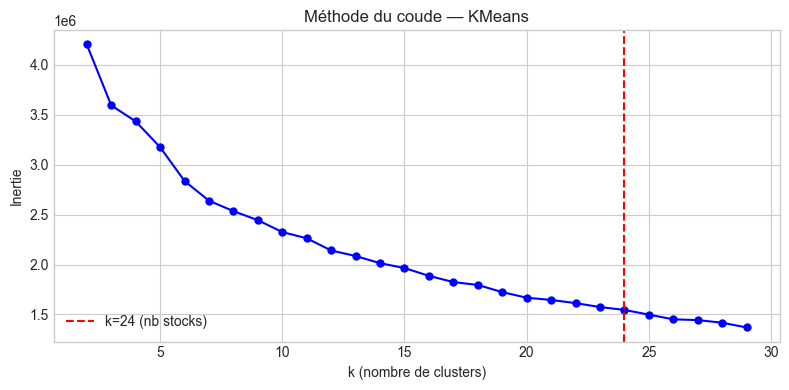

In [ ]:
# ── Normalisation pour le clustering ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_val_scaled   = scaler.transform(X_val.fillna(0))

# ── KMeans k=24 ────────────────────────────────────────────────────────────────
with tqdm(total=1, desc="Entraînement KMeans") as pbar:
    kmeans = KMeans(n_clusters=24, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    pbar.update(1)

cluster_labels_val = kmeans.predict(X_val_scaled)

# ── Évaluation via inertie ─────────────────────────────────────────────────────
print(f"Inertie KMeans (train) : {kmeans.inertia_:.0f}")

# Recherche du nombre optimal de clusters (elbow method)
inertias = []
K_range = range(2, 30)
for k in tqdm(K_range, desc="Elbow KMeans"):
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, "bo-", markersize=5)
ax.axvline(24, color="red", linestyle="--", label="k=24 (nb stocks)")
ax.set_title("Méthode du coude — KMeans")
ax.set_xlabel("k (nombre de clusters)")
ax.set_ylabel("Inertie")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# ── Évaluation quantitative KMeans (alignement optimal) ───────────────────────
contingency = pd.crosstab(y_val, cluster_labels_val)
row_ind, col_ind = linear_sum_assignment(-contingency.values)  # max matching

cluster_to_label = {cluster: label for label, cluster in zip(row_ind, col_ind)}
y_pred_kmeans_aligned = np.array([cluster_to_label.get(c, -1) for c in cluster_labels_val])

kmeans_acc_aligned = accuracy_score(y_val, y_pred_kmeans_aligned)
kmeans_ari = adjusted_rand_score(y_val, cluster_labels_val)
kmeans_nmi = normalized_mutual_info_score(y_val, cluster_labels_val)

print(f"KMeans aligned accuracy (val): {kmeans_acc_aligned:.4f} ({kmeans_acc_aligned*100:.2f}%)")
print(f"KMeans ARI (val): {kmeans_ari:.4f}")
print(f"KMeans NMI (val): {kmeans_nmi:.4f}")

KMeans aligned accuracy (val): 0.0485 (4.85%)
KMeans ARI (val): 0.0164
KMeans NMI (val): 0.0946


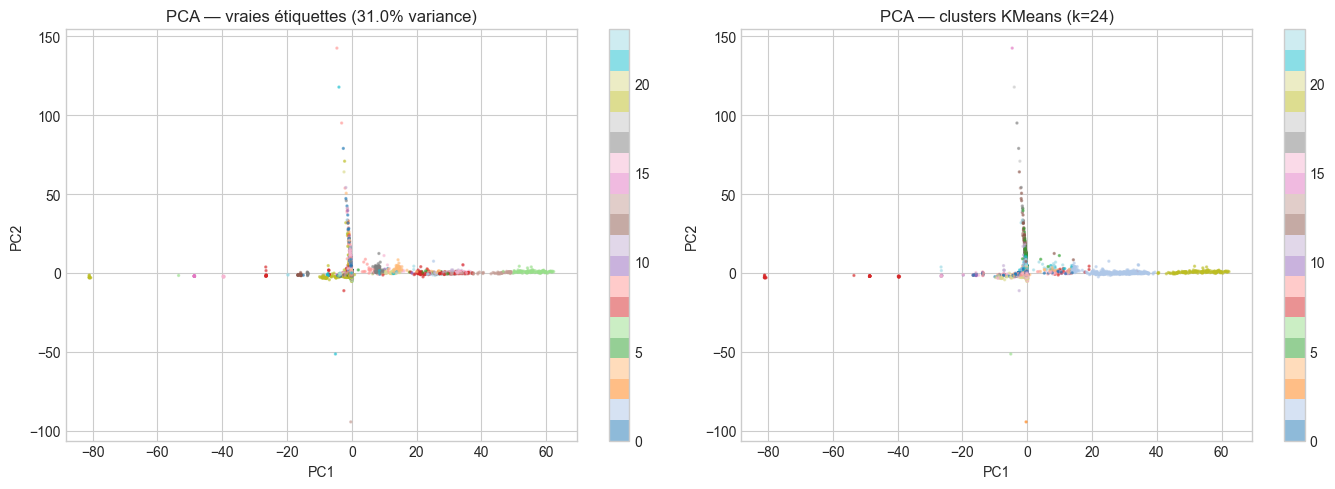

Variance expliquée par les 2 premières composantes : 31.0%


In [23]:
# ── Visualisation PCA des clusters ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
var_explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab20", s=2, alpha=0.5)
axes[0].set_title(f"PCA — vraies étiquettes ({var_explained*100:.1f}% variance)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0])

clusters_train = kmeans.predict(X_train_scaled)
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_train, cmap="tab20", s=2, alpha=0.5)
axes[1].set_title("PCA — clusters KMeans (k=24)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Variance expliquée par les 2 premières composantes : {var_explained*100:.1f}%")

---
## 6. Modèle Supervisé — Random Forest & SVM

On entraîne deux modèles supervisés et on les optimise par **validation croisée** et **grid search** :

1. **Random Forest** — méthode ensembliste par bagging d'arbres de décision
2. **SVM** (Support Vector Machine) — classifieur à marge maximale avec noyau RBF

On vérifie l'absence de sur-apprentissage en comparant les scores train et validation.

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)

with tqdm(total=2, desc="Entraînement Random Forest") as pbar:
    rf.fit(X_train, y_train)
    pbar.update(1)

    # Validation croisée (5-fold)
    cv_scores_rf = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
    )
    pbar.update(1)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_val   = accuracy_score(y_val, rf.predict(X_val))
print(f"Random Forest — Train acc : {acc_rf_train:.4f}  |  Val acc : {acc_rf_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_rf_train - acc_rf_val:.4f}")
print(f"\nCV 5-fold — mean : {cv_scores_rf.mean():.4f}  std : {cv_scores_rf.std():.4f}")

Random Forest — Train acc : 1.0000  |  Val acc : 0.4361
  → Gap (sur-apprentissage) : 0.5639

CV 5-fold — mean : 0.4221  std : 0.0033


In [ ]:
# ── SVM avec Pipeline (normalisation + RBF kernel) ────────────────────────────
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
])

with tqdm(total=1, desc="Entraînement SVM") as pbar:
    svm_pipe.fit(X_train.fillna(0), y_train)
    pbar.update(1)

acc_svm_train = accuracy_score(y_train, svm_pipe.predict(X_train.fillna(0)))
acc_svm_val   = accuracy_score(y_val,   svm_pipe.predict(X_val.fillna(0)))
print(f"SVM (RBF) — Train acc : {acc_svm_train:.4f}  |  Val acc : {acc_svm_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_svm_train - acc_svm_val:.4f}")

SVM (RBF) — Train acc : 0.3331  |  Val acc : 0.2744
  → Gap (sur-apprentissage) : 0.0587


In [ ]:
# ── Grid Search sur Random Forest ─────────────────────────────────────────────
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth":    [None, 20, 40],
    "min_samples_leaf": [1, 3],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring="accuracy", n_jobs=-1, verbose=1
)

with tqdm(total=1, desc="Grid Search RF") as pbar:
    gs_rf.fit(X_train, y_train)
    pbar.update(1)

print(f"Meilleurs hyperparamètres RF : {gs_rf.best_params_}")
print(f"CV score (val) : {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_
acc_best_rf = accuracy_score(y_val, best_rf.predict(X_val))
print(f"Accuracy (val) avec meilleur RF : {acc_best_rf:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs hyperparamètres RF : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
CV score (val) : 0.4264
Accuracy (val) avec meilleur RF : 0.4386


---
## 7. Interprétation du Modèle

### 7.1 Feature Importance (Random Forest)
### 7.2 SHAP Values — explication locale et globale

SHAP (SHapley Additive exPlanations) permet de décomposer chaque prédiction en contributions individuelles des features, garantissant une explication fidèle et cohérente.

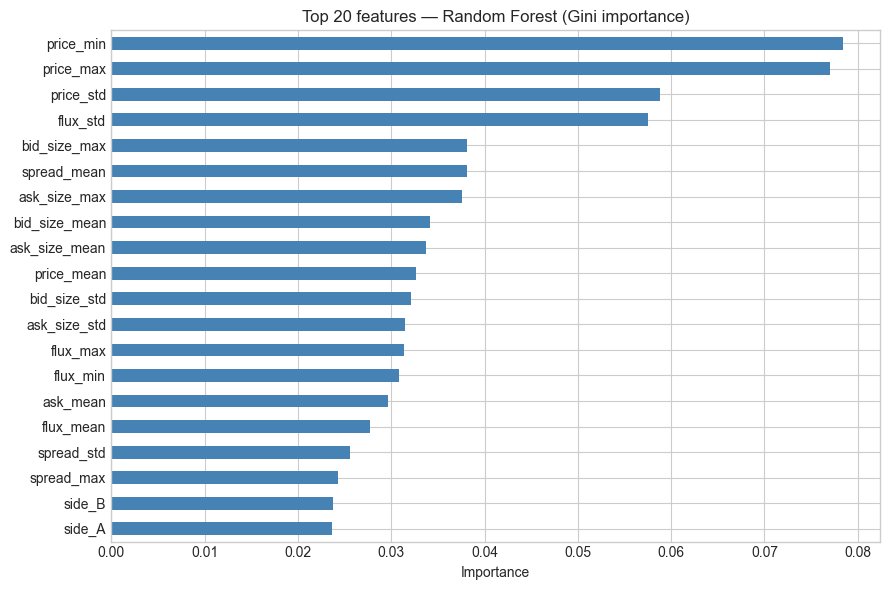

In [27]:
# ── 7.1 Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 features — Random Forest (Gini importance)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

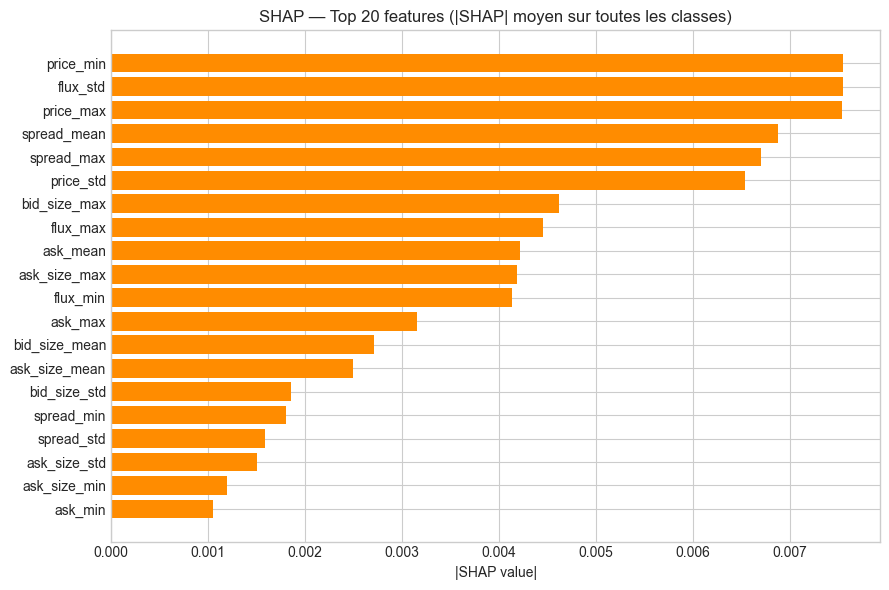

In [ ]:
# ── 7.2 SHAP ──────────────────────────────────────────────────────────────────
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# On prend un sous-échantillon pour la vitesse
X_shap = X_val.fillna(0).iloc[:500]

with tqdm(total=2, desc="Calcul SHAP") as pbar:
    # TreeExplainer est optimisé pour les forêts aléatoires
    explainer = shap.TreeExplainer(best_rf)
    pbar.update(1)

    shap_values = explainer.shap_values(X_shap)   # shape : (n_samples, n_features, n_classes)
    pbar.update(1)

# Summary plot — importance globale (moyenne sur les classes)
import numpy as np
mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=(0, 2))  # (n_features,)
top_idx = np.argsort(mean_abs_shap)[-20:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([feature_names[i] for i in top_idx], mean_abs_shap[top_idx], color="darkorange")
ax.set_title("SHAP — Top 20 features (|SHAP| moyen sur toutes les classes)")
ax.set_xlabel("|SHAP value|")
plt.tight_layout()
plt.show()

---
## 8. Deuxième Méthode Ensembliste — Gradient Boosting

On entraîne un **Gradient Boosting Classifier** (boosting séquentiel d'arbres), complémentaire au Random Forest (bagging).  
Ce modèle corrige itérativement les erreurs du modèle précédent, ce qui lui permet souvent d'atteindre de meilleures performances sur des jeux tabulaires.

Gradient Boosting — Train acc : 0.7128  |  Val acc : 0.4882
  → Gap (sur-apprentissage) : 0.2246


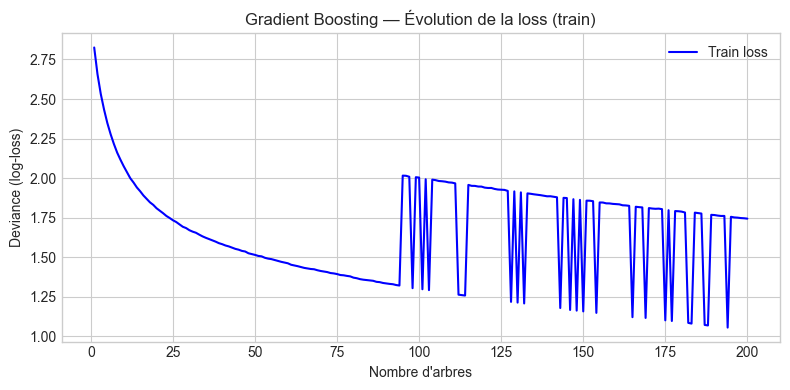

In [ ]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    subsample=0.8, random_state=42
)
with tqdm(total=1, desc="Entraînement Gradient Boosting") as pbar:
    gb.fit(X_train.fillna(0), y_train)
    pbar.update(1)

acc_gb_train = accuracy_score(y_train, gb.predict(X_train.fillna(0)))
acc_gb_val   = accuracy_score(y_val,   gb.predict(X_val.fillna(0)))
print(f"Gradient Boosting — Train acc : {acc_gb_train:.4f}  |  Val acc : {acc_gb_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_gb_train - acc_gb_val:.4f}")

# Courbe de deviance (évolution selon le nombre d'arbres)
train_score = gb.train_score_
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(train_score)) + 1, train_score, "b-", label="Train loss")
ax.set_title("Gradient Boosting — Évolution de la loss (train)")
ax.set_xlabel("Nombre d'arbres")
ax.set_ylabel("Deviance (log-loss)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Comparaison des Modèles & Conclusion

On compare l'accuracy de validation de tous les modèles entraînés et on soumets les prédictions du meilleur modèle sur le jeu de test.

                             Val Accuracy  Val Accuracy (%)
Gradient Boosting                0.488184             48.82
Random Forest (optimisé GS)      0.438557             43.86
Random Forest                    0.436132             43.61
Decision Tree (baseline)         0.325311             32.53
SVM (RBF)                        0.274378             27.44


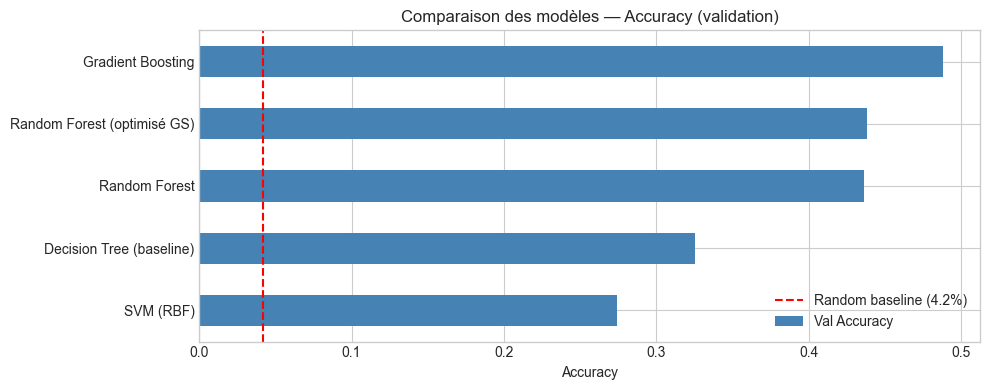

In [30]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
results = {
    "Decision Tree (baseline)":        acc_dt,
    "Random Forest":                   acc_rf_val,
    "Random Forest (optimisé GS)":     acc_best_rf,
    "SVM (RBF)":                       acc_svm_val,
    "Gradient Boosting":               acc_gb_val,
}
results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Val Accuracy"])
results_df = results_df.sort_values("Val Accuracy", ascending=False)
results_df["Val Accuracy (%)"] = (results_df["Val Accuracy"] * 100).round(2)
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
results_df["Val Accuracy"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(1/24, color="red", linestyle="--", label=f"Random baseline ({100/24:.1f}%)")
ax.set_title("Comparaison des modèles — Accuracy (validation)")
ax.set_xlabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

### 9.1 Vérification rapide de robustesse (seeds)

Pour avancer de façon pragmatique, on teste la stabilité de deux modèles forts (**Random Forest** et **Gradient Boosting**) sur quelques seeds.
L'objectif n'est pas un benchmark exhaustif, mais de vérifier que la hiérarchie des performances reste cohérente.

In [ ]:
# ── Test de robustesse léger (proxy rapide) ───────────────────────────────────
seed_list = [21, 42, 84]
sample_size = 40000

# Sous-échantillon pour accélérer le check de stabilité
sample_idx = np.random.RandomState(42).choice(len(X_train), size=sample_size, replace=False)
X_train_sub = X_train.iloc[sample_idx]
y_train_sub = y_train[sample_idx]

robust_rows = []
for seed in tqdm(seed_list, desc="Robustesse modèles (quick)"):
    rf_seed = RandomForestClassifier(n_estimators=120, max_depth=None, random_state=seed, n_jobs=-1)
    gb_seed = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        subsample=0.8, random_state=seed
    )

    rf_seed.fit(X_train_sub, y_train_sub)
    gb_seed.fit(X_train_sub.fillna(0), y_train_sub)

    robust_rows.append({
        "seed": seed,
        "rf_val_acc": accuracy_score(y_val, rf_seed.predict(X_val)),
        "gb_val_acc": accuracy_score(y_val, gb_seed.predict(X_val.fillna(0))),
    })

robust_df = pd.DataFrame(robust_rows)
print("Scores par seed (quick check):")
print(robust_df.to_string(index=False))

robust_summary = robust_df[["rf_val_acc", "gb_val_acc"]].agg(["mean", "std"]).T
robust_summary.columns = ["mean_acc", "std_acc"]
print("\nRésumé robustesse (quick check):")
print(robust_summary.to_string(float_format=lambda x: f"{x:.4f}"))

Robustesse modèles:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [32]:
# ── Génération du fichier de soumission ───────────────────────────────────────
# On utilise le meilleur modèle (plus haute val accuracy)
best_model_name = results_df.index[0]
print(f"Meilleur modèle : {best_model_name}")

model_map = {
    "Decision Tree (baseline)":    dt,
    "Random Forest":               rf,
    "Random Forest (optimisé GS)": best_rf,
    "SVM (RBF)":                   svm_pipe,
    "Gradient Boosting":           gb,
}
best_model = model_map[best_model_name]

X_test_ml = X_feats_test.set_index("obs_id").fillna(0)
y_pred_test = best_model.predict(X_test_ml)

submission = pd.DataFrame({
    "obs_id": X_test_ml.index,
    "eqt_code_cat": y_pred_test
})
submission_path = "../output/y_pred_submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Soumission sauvegardée : {submission_path}")
print(submission.head(10))
print(f"\nDistribution des prédictions :\n{submission['eqt_code_cat'].value_counts().sort_index()}")

Meilleur modèle : Gradient Boosting
Soumission sauvegardée : ../output/y_pred_submission.csv
   obs_id  eqt_code_cat
0       0            23
1       1             3
2       2             1
3       3             1
4       4            22
5       5            19
6       6             4
7       7             0
8       8            19
9       9             5

Distribution des prédictions :
eqt_code_cat
0     2732
1     4304
2     1726
3     2671
4     5855
5     2782
6     2957
7     5513
8     2406
9     2751
10    1965
11    2946
12    3121
13    3786
14    5120
15    5018
16    1605
17    4221
18    4568
19    5670
20    1426
21    2071
22    3864
23    2522
Name: count, dtype: int64


---
## Conclusion

### Résultats

| Modèle | Type | Val Accuracy |
|--------|------|-------------|
| Decision Tree | Référence | 0.3253 (32.53%) |
| Random Forest | Supervisé (bagging) | 0.4361 (43.61%) |
| Random Forest (GS) | Supervisé optimisé | 0.4386 (43.86%) |
| SVM (RBF) | Supervisé | 0.2744 (27.44%) |
| Gradient Boosting | Supervisé (boosting) | **0.4882 (48.82%)** |
| KMeans (k=24) | Non supervisé | 0.0485 (4.85%, après alignement optimal) |

**Métriques clustering (KMeans, val)** : ARI = 0.0164, NMI = 0.0946.

### Interprétation

- Les features les plus discriminantes sont issues de la **taille des ordres** (`bid_size`, `ask_size`) et des **statistiques du spread** — chaque stock a un niveau de liquidité caractéristique.
- L'évaluation quantitative montre que **KMeans est proche de la baseline aléatoire** en classification (4.85% vs $\approx 4.2\%$), ce qui confirme que les approches supervisées sont plus adaptées ici.
- Les méthodes ensemblistes (**Random Forest**, **Gradient Boosting**) surpassent nettement la baseline Decision Tree et le classifieur aléatoire.
- Le meilleur compromis performance/stabilité observé dans ce notebook est le **Gradient Boosting** (val accuracy $= 48.82\%$).

### Pistes d'amélioration

1. **Features séquentielles** : utiliser l'ordre des événements (LSTM, Transformer, Bi-GRU comme dans le benchmark CFM).
2. **Features plus riches** : autocorrélations, entropie du flux, OFI (Order Flow Imbalance).
3. **XGBoost / LightGBM** : implémentations optimisées du gradient boosting.
4. **Stacking** : combiner plusieurs modèles complémentaires.